In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
data_path = '../../data/1minute_data_austin/1minute_data_austin.csv'
data_raw = pd.read_csv(data_path)

In [33]:
columns = data_raw.columns
home_ids = data_raw["dataid"].unique()
num_rows = data_raw["dataid"].value_counts()

In [95]:
def get_single_home(home_num): 
    df_home = data_raw.loc[data_raw["dataid"] == home_ids[home_num]]
    df_home = df_home.drop(columns = "dataid")
    df_home = df_home.dropna(axis=1, how="all")
    df_home = df_home.set_index("localminute")
    df_home.index = pd.to_datetime(df_home.index, utc = True)
    return df_home

In [96]:
df_home = get_single_home(0)
df_home_hourly = df_home.resample("H").mean()

/var/folders/0h/cpmzljqs7y98z5g9zx33_kmc0000gn/T/ipykernel_9066/2855660111.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_home_hourly = df_home.resample("H").mean()


<Axes: xlabel='localminute'>

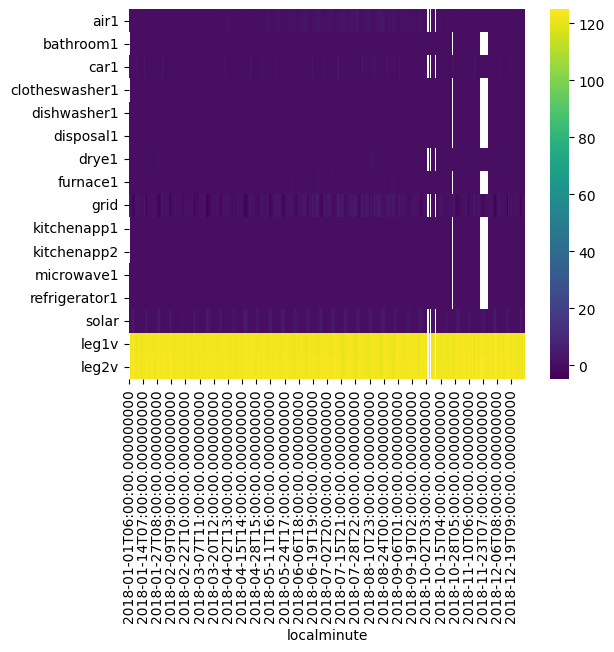

In [97]:
sns.heatmap(data = df_home_hourly.T, cmap = "viridis")

<Axes: xlabel='localminute'>

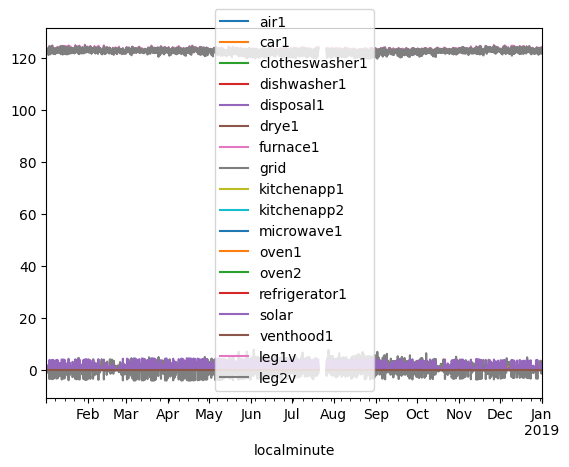

In [93]:
df_home_hourly.plot()